# Peer agreement vs paid AI judges on held-out NL→FOL — T1 demo

**Setting.** You have a natural-language sentence and a candidate first-order-logic (FOL) formula, and **no gold
formula**. The question: is the candidate *faithful* to the sentence?

**This artifact (T1).** It compares the frozen **peer-agreement consensus** metric `c_score_align` with the **paid API LLM
judges** a practitioner would actually deploy. The consensus metric scores a candidate by how far it sits, under z3
equivalence modulo vocabulary, from the pool of other systems' formalisations of the same sentence. The comparison
also includes its PEER+TEXT fusion `p_peer_text` and a cross-fitted stack of all 28 baselines (`S4_full`).
The test set is the held-out dataset **E**: 8,507 real candidates from many NL→FOL systems over 700 sentences. The labels
come from prover-checked equivalence with the gold formula, after symbol alignment.

The API comparators scored by `method.py` are:
- **gemini-2.5-flash-lite**, a rubric-A JSON judge, run on the original and nonce-disguised views;
- **gpt-4.1-nano**, a one-token P(YES) judge, run on both views;
- **gemini-3.1-pro-preview**, the frontier judge, on a 284-row frame;
- an API **round trip**: FOL → English with flash-lite, then DeBERTa NLI and mpnet cosine against the sentence;
- API **SC-5** self-consistency: 5 nano samples at T = 0.7, compared by z3 equivalence modulo vocabulary.

**Full-run headline results** (primary population R_AB, n = 2,686; sentence-cluster bootstrap B = 2000). Every Δ is
**strat**, the within-stratum AUROC difference:
- **(a) CONFIRMED.** `c_score_align` beats the flash-lite disguised judge: stratified AUROC 0.741 vs 0.642,
  Δ = +0.099 [0.049, 0.146]. On the long-sentence pool (L25 + L20 + EXC) the gap is +0.116.
- **(b) CONFIRMED.** Consensus adds signal on top of the stack of all baselines: [S4_full + c] − S4_full = +0.039
  [0.021, 0.057].
- **(d) CONFIRMED.** Consensus reaches 0.957× the frontier judge's AUROC at about 3% of its cost per item.
- Caveat: consensus has **no** advantage on short FOLIO sentences (CTRL). Its advantage sits in long, conditioned
  sentences and sentences with exceptions.

**What this notebook runs.** `method.py` is a staged, cached pipeline: about 30 `--stage` functions that call OpenRouter
APIs, GPU models and z3. The paid and GPU stages cannot rerun in a short demo. This notebook therefore works in two parts:
1. It re-runs the **CPU parts of the original code**: the strict parse gate (`strict_parse_ok` with the shared z3 FOL
   grammar) and the full **T1 statistics** (`src/api_bar.py` and `src/analyse_T1.py`: stratified AUROC, paired
   sentence-cluster bootstrap, head-on criterion (a), nested stack criterion (b), complexity curves, recall by error type).
2. It runs them on a **100-row demo subset**. Each row carries the metric scores **cached from the full run**
   (`results/per_item_T1.jsonl`; every LLM call was cached in `results/llm_cache.jsonl`).

Demo-subset numbers come from about 88 labelled rows, so they are noisy. Each one is shown next to its full-run
reference value.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver — NOT on Colab, always install (the shared FOL grammar converts every parsed formula to z3)
_pip('z3-solver==4.15.4.0')

# numpy, scipy, scikit-learn, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original import block of method.py (argparse/asyncio/os/time kept for fidelity; loguru logging not needed here) ---
from __future__ import annotations

import argparse
import asyncio
import hashlib
import json
import math
import os
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

sys.setrecursionlimit(10000)

# --- imports used by the ported src/ modules (fol.py, api_bar.py, analyse_T1.py) ---
import re
import types
import numpy as np
import z3
from scipy.stats import rankdata

# --- notebook-only: tables and plots ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_Jhw6i0bFXdo3/round-3/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("examples:", len(data["examples"]))

T1 demo subset of held-out NL->FOL set E: 88 labelled R_AB rows (11 ERROR + 11 CORRECT per source stratum, one per sentence, seed 0) + 12 unparseable candidates, with every oriented metric score (higher = more likely unfaithful) cached from the full run, plus full-run reference numbers (n = 2,686).
examples: 100


## Configuration

Every tunable parameter is set here. The demo values keep the whole notebook well under 10 minutes. The original
full-run values are in the comments; the original population is all 2,686 R_AB rows, which is not shipped here.

In [5]:
MAX_ROWS = 100        # rows of the demo subset to use (demo max: 100; original: all 8,507 candidates of E)
BOOT_B = 2000           # sentence-cluster bootstrap replicates for every CI and paired delta (original: B = 2000)
COMPLEXITY_B = 1000     # bootstrap replicates inside the complexity cells (original: 1000)
FA_LEVELS = (0.10, 0.20)   # matched false-alarm operating points for recall-by-error-type (original: (0.10, 0.20))
MIN_NEG_FOR_THRESHOLD = 20  # CORRECT rows needed to set a matched-FA threshold (original: 50; the demo has 44)

## The `method.py` pipeline and what runs here

The original is run as `PYTHONHASHSEED=0 python method.py --stage NAME [--limit N]`. The T1 stages (iteration 3) are
listed below:

| stage (`method.py`) | what it does | in this notebook |
|---|---|---|
| `prep` / `t1_prep` | label-blind unit table; **strict parse gate** (`strict_parse_ok`, fol.py + z3); nonce disguise | **re-run** (parse gate) + shown (disguise) |
| `judges` | flash-lite rubric-A JSON judge + gpt-4.1-nano P(YES) judge, original + disguised views | cached scores |
| `sc_gen` / `sc_score` | SC-5 samples (nano, T=0.7) and z3 equivalence-modulo-vocabulary scoring | cached scores |
| `verbalise` + `nli` | round trip: FOL → English (flash-lite), then DeBERTa NLI / mpnet vs the sentence (GPU) | cached scores |
| `strong` | gemini-3.1-pro-preview frontier judge on the 284-row frame | cached scores (full-run reference only) |
| `t1_pilot` / `t1_freeze` | label-blind pilots; freeze `prereg_T1.json` by sha256 before any sweep score | not needed (frozen) |
| `t1_analysis` | join + every T1 analysis (`src/analyse_T1.py`), tables, verdict | **re-run** on the demo subset |

**Orientation convention.** Every score is oriented so that *higher = more likely UNFAITHFUL*. An unparseable
candidate gets the worst value (1.0) from every metric, so it is counted, never silently dropped.

## Demo subset

The subset has 100 rows, one per sentence, drawn with seed 0:
- 88 rows from the primary population: `E_POOL`, parseable, label regime **R_AB** (tier A + tier B labels). Each of the
  four source strata contributes 11 ERROR and 11 CORRECT rows. The strata are L25 (long sentences), L20, EXC
  (sentences with exceptions) and CTRL (short FOLIO controls).
- 12 **unparseable** candidates, which demonstrate the coverage rule.

The full run's per-item table stores the local baselines as `local__X`. `src/join_T1.py` exposes them as `L:X`,
and the next cell restores that naming.

In [6]:
rows = []
for x in data["examples"][:MAX_ROWS]:
    x = dict(x)
    for k in list(x):
        if k.startswith("local__"):
            x["L:" + k[len("local__"):]] = x[k]
    rows.append(x)
REF = data["full_run_reference"]

print(f"{len(rows)} rows, {len({r['sentence_id'] for r in rows})} sentences")
print("pool x parse_ok:", dict(Counter((r['pool'], r['parse_ok']) for r in rows)))
print("final label   :", dict(Counter(r['final_label'] for r in rows)))
print("stratum x y   :", dict(sorted(Counter((r['source_stratum'], r['y_R_AB']) for r in rows if r['in_R_AB']).items())))
pd.set_option("display.max_colwidth", 90)
pd.DataFrame([{k: r[k] for k in ("source_stratum", "system", "final_label", "text", "candidate_fol")} for r in rows[:5]])

100 rows, 100 sentences
pool x parse_ok: {('E_POOL', True): 88, ('E_POOL', False): 12}
final label   : {'ERROR': 44, 'CORRECT': 44, 'UNPARSEABLE': 12}
stratum x y   : {('CTRL', 0): 11, ('CTRL', 1): 11, ('EXC', 0): 11, ('EXC', 1): 11, ('L20', 0): 11, ('L20', 1): 11, ('L25', 0): 11, ('L25', 1): 11}


,source_stratum,system,final_label,text,candidate_fol
0,L25,G1b:meta-llama/llama-3.3-70b-instruct,ERROR,A scientist who studies astronomy or astrophysics but not both will have a broader kno...,∀x (Scientist(x) ∧ ((StudiesAstronomy(x) ⊕ StudiesAstrophysics(x)) → (∀y (Scientist(y)...
1,L25,G2:qwen/qwen3-235b-a22b-2507,CORRECT,"An athlete qualifies for a competition if they meet the minimum age requirement, have ...",∀x (Athlete(x) → (QualifiesForCompetition(x) ↔ (MeetsAgeRequirement(x) ∧ HighSkillLeve...
2,L25,G1b:meta-llama/llama-3.3-70b-instruct,ERROR,A musical instrument is a string instrument if it produces sound through the vibration...,∀x (StringInstrument(x) ↔ (ProducesSoundThroughVibration(x) ∧ (PlaysByPlucking(x) ∨ Pl...
3,L25,G4:deepseek/deepseek-v3.2,ERROR,"An entity is a university when it is an institution of higher learning, offers a wide ...",∀x (University(x) ↔ (InstitutionOfHigherLearning(x) ∧ OffersWideRangeOfAcademicProgram...
4,L25,G2:qwen/qwen3-235b-a22b-2507,CORRECT,"A vehicle that is designed for off-road use, has four-wheel drive, and is built for ru...","∀x (Vehicle(x) ∧ DesignedFor(x, offRoadUse) ∧ HasFourWheelDrive(x) ∧ BuiltFor(x, rugge..."


## Stage `prep`: the strict parse gate (coverage)

All metrics share one FOL grammar, `src/labeller/fol.py`. It reads FOLIO/MALLS Unicode notation into an AST and
converts that AST to z3. `labeller.parse_ok` requires both a parse and a successful z3 conversion. `method.py`'s
`strict_parse_ok` adds one more check. fol.py reads a dangling trailing connective such as `A(x) ∧` as an atom named
`None`, so the check requires every atom to have a name; truncated outputs therefore count as unparseable.

The next cell is the shared grammar, copied verbatim from `src/labeller/fol.py`.

In [7]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")


OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}


PREC = {"iff": 1, "xor": 3, "imp": 2, "or": 3, "and": 4}  # FIX (iter-3 review): ⊕ binds like ∨, tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("->", "→").replace("<->", "↔").replace("&", "∧").replace("|", "∨")
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)

The next cell holds `parse_ok` (from `src/labeller/labeller.py`) and `atoms` (from `src/labeller/repair_census.py`),
followed by `strict_parse_ok`, which is **verbatim from `method.py`**. The only change is that its three
`from src.labeller… import` lines point to the definitions above.

In [8]:
def parse_ok(fol_str: str | None) -> bool:
    """Parses with the shared grammar AND converts to z3."""
    if fol_str is None:
        return False
    try:
        e = parse(fol_str)
        equivalent(e, e, 1000)
        return True
    except Exception:  # noqa: BLE001
        return False


def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def strict_parse_ok(fol) -> bool:
    """labeller.parse_ok AND no atom without a name (fol.py accepts a dangling trailing connective, e.g. 'A(x) ∧', by
    reading an atom named None at end of input; such truncated outputs are unparseable)."""
    # (notebook: parse / parse_ok / atoms are defined in the cells above instead of imported from src.labeller)
    if not fol or not fol.strip() or not parse_ok(fol):
        return False
    try:
        return all(isinstance(a[1], str) and a[1] for a in atoms(parse(fol)))
    except Exception:  # noqa: BLE001
        return False

In [9]:
t0 = time.time()
parse_flags = {r["canonical_key"]: strict_parse_ok(r["candidate_fol"]) for r in rows}
n_ok = sum(parse_flags.values())
agree = sum(parse_flags[r["canonical_key"]] == r["parse_ok"] for r in rows)
print(f"strict_parse_ok on {len(rows)} candidates: {n_ok} parseable, {len(rows) - n_ok} unparseable "
      f"({time.time() - t0:.1f}s)")
print(f"agreement with the stored stage-prep flag: {agree}/{len(rows)}")
print("\nUnparseable candidates and why (fol.py error):")
for r in rows:
    if not parse_flags[r["canonical_key"]]:
        try:
            e = parse(r["candidate_fol"]); why = "parses, but z3 conversion / atom check fails"
        except Exception as ex:
            why = str(ex)[:60]
        print(f"  - {r['candidate_fol'][:80]!r}\n      -> {why}")

strict_parse_ok on 100 candidates: 88 parseable, 12 unparseable (0.2s)
agreement with the stored stage-prep flag: 100/100

Unparseable candidates and why (fol.py error):
  - '∀x ∀y (EndangeredIn(x, y) ↔ (Declining(Population(x)) ∧ ∃z (Threat(z) ∧ Faces(x,'
      -> expected ) got (
  - '∀x (Book(x) → (MysteryNovel(x) ↔ (TellStory(x, crimeOrEnigma) ∧ RequireSolve(x, '
      -> expected ) got None
  - 'Habitat(Rainforest, ∃x (Plant(x) ∨ Animal(x))) ∧ RegulateClimate(Rainforest) ∧ A'
      -> expected ) got x
  - '∀x (Horse(x) ∧ FallsInRace(x) → PosesRisksToRider(x, RiderOf(x)))'
      -> expected ) got (
  - '∀x (Lipstick(x) ∧ In(x, rougeDiorSet) ∧ LunarNewYearLimitedEdition(x) → (¬HasInO'
      -> bad char at 102: '"rosewood"'
  - '∀x (SolarSystem(x) → ∃y (CelestialBody(y) ∧ OrbitsAround(y, CentralStar(x)) ∧ Ca'
      -> expected ) got (
  - '∀x (CitizenOf(x, lawtonPark) → UseZipCode(x, 98199))'
      -> bad char at 45: '98199))'
  - '∀x (ScientificStudy(x) → (FollowsScientificMethod(x)

**Coverage rule.** An unparseable candidate is never dropped. Every metric gives it the worst oriented score (1.0),
and a JSON-failed judge call keeps its failure status. The next cell shows the cached scores of a few unparseable rows.

In [10]:
SHOW = ["c_score_align", "p_peer_text", "judge_cheap_disg", "judge_cheap2_orig", "rt_nli_min", "sc5_eq_frac", "S4_full_oof"]
unp = [r for r in rows if not r["parse_ok"]]
pd.DataFrame([{**{"candidate_fol": r["candidate_fol"][:50]}, **{m: r.get(m) for m in SHOW},
               "judge_cheap_disg__status": r.get("judge_cheap_disg__status")} for r in unp[:5]])

,candidate_fol,c_score_align,p_peer_text,judge_cheap_disg,judge_cheap2_orig,rt_nli_min,sc5_eq_frac,S4_full_oof,judge_cheap_disg__status
0,"∀x ∀y (EndangeredIn(x, y) ↔ (Declining(Population(",1.0,1.0,1.0,1.0,1.0,1.0,0.999949,fail
1,"∀x (Book(x) → (MysteryNovel(x) ↔ (TellStory(x, cri",1.0,1.0,1.0,1.0,1.0,1.0,0.999918,fail
2,"Habitat(Rainforest, ∃x (Plant(x) ∨ Animal(x))) ∧ R",1.0,1.0,1.0,1.0,1.0,1.0,0.999918,fail
3,∀x (Horse(x) ∧ FallsInRace(x) → PosesRisksToRider(,1.0,1.0,1.0,1.0,1.0,1.0,0.999949,fail
4,"∀x (Lipstick(x) ∧ In(x, rougeDiorSet) ∧ LunarNewYe",1.0,1.0,1.0,1.0,1.0,1.0,0.999897,fail


## Nonce disguise and the cached metric scores

The API judges score each pair twice. The **original** view is the sentence and formula as given. The **disguised**
view replaces content words by nonce words consistently on both sides (the exp-D `disguise_item`). The disguised view
checks whether a judge relies on having seen public gold formulas. On E, flash-lite's disguised view turned out to be
its *better* view (+0.061 pooled AUROC).

What each cached column measures (oriented: higher = more likely unfaithful):

| column | measures |
|---|---|
| `c_score_align` | peer-agreement **consensus**: disagreement, under z3 equivalence modulo vocabulary (after symbol alignment), between the candidate and the other systems' formalisations of the same sentence |
| `p_peer_text` | frozen PEER+TEXT logistic fusion of consensus features and text-side features |
| `judge_cheap_{orig,disg}` | 1 − P(faithful) from the flash-lite rubric-A JSON judge |
| `judge_cheap2_{orig,disg}` | 1 − P(YES) from gpt-4.1-nano's YES/NO next-token log-probs |
| `rt_nli_min` | round trip: 1 − min(P_entail(text ⇒ v), P_entail(v ⇒ text)), where v is flash-lite's verbalisation of the FOL |
| `sc5_eq_frac` | SC-5: 1 − share of 5 nano resamples equivalent to the candidate |
| `S4_full_oof` | cross-fitted L2-logistic stack of all 28 baselines (out-of-fold) |
| `S4_full_plus_c_score_align_oof` | the same stack plus `c_score_align` |

In [11]:
ex = next(r for r in rows if r["parse_ok"] and r.get("text_d") and r["source_stratum"] == "EXC")
print("ORIGINAL VIEW\n  text :", ex["text"], "\n  fol  :", ex["candidate_fol"])
print("DISGUISED VIEW\n  text :", ex["text_d"], "\n  fol  :", ex["fol_d"])
print("gold :", ex["reference_fol"])
print("label:", ex["final_label"], "| error ops (candidate vs gold):", ex["error_ops"])
print({m: ex.get(m) for m in SHOW})

ORIGINAL VIEW
  text : A bird can fly unless it is a flightless bird. 
  fol  : ∀x (Bird(x) ∧ ¬FlightlessBird(x) → CanFly(x))
DISGUISED VIEW
  text : A situvso can mapatme unless it is a linidu situvso. 
  fol  : ∀x (Situvso(x) ∧ ¬LiniduSituvso(x) → CanMapatme(x))
gold : ∀x (Bird(x) ∧ ¬FlightlessBird(x) → CanFly(x))
label: CORRECT | error ops (candidate vs gold): None
{'c_score_align': 0.6, 'p_peer_text': 0.329942, 'judge_cheap_disg': 0.05, 'judge_cheap2_orig': 0.047428, 'rt_nli_min': 0.032724, 'sc5_eq_frac': 0.6, 'S4_full_oof': 0.068333}


## Statistics core (`src/api_bar.py`, verbatim)

The functions below are copied without change:
- **`auroc`**: the Mann-Whitney AUROC, with ties counted as ½.
- **`strat_auroc`**: the within-stratum AUROC. Only (ERROR, CORRECT) pairs from the same source stratum count, which
  removes the effect of stratum composition.
- **`ClusterBoot`**: resamples *sentences* with replacement. Every metric uses the same resamples, so every Δ is paired.
- **`delong`**: the DeLong paired test.
- **matched-FA thresholds** and **`recall_at`**: recall at a fixed false-alarm rate.
- **`nested_delta`**: OOF(S + X) − OOF(S) on the same rows.

`analyse_T1.py` calls these through the module alias `AB`, which is rebuilt here as a namespace.

In [12]:
def auroc(y, s) -> float:
    """Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def tie_rate(y, s) -> float:
    """Share of (ERROR, CORRECT) pairs whose scores are exactly tied."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    pos, neg = s[y == 1], s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    vals, inv = np.unique(np.concatenate([pos, neg]), return_inverse=True)
    cp = np.bincount(inv[:len(pos)], minlength=len(vals))
    cn = np.bincount(inv[len(pos):], minlength=len(vals))
    return float((cp * cn).sum() / (len(pos) * len(neg)))


def strat_auroc(y, s, stratum) -> float:
    """Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    """Sentence-clustered bootstrap index sets: resample sentence ids with replacement (fixed seed); every metric on a
    row set uses the IDENTICAL resamples, which makes deltas paired."""

    def __init__(self, clusters: Sequence[str], b: int = 2000, seed: int = 0):
        by = defaultdict(list)
        for i, c in enumerate(clusters):
            by[c].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = []
        for _ in range(b):
            pick = rng.integers(0, len(keys), len(keys))
            self.idx.append(np.concatenate([arr[j] for j in pick]))
        self.n_clusters = len(keys)


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def paired_boot(y, a, c, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    """Paired delta stat(a) - stat(c) on identical rows; percentile CI over cluster resamples; one-sided
    p = share of resampled deltas <= 0. stat in {'pooled', 'strat'} (strat needs `stratum`)."""
    y = np.asarray(y)
    a = np.asarray(a, float)
    c = np.asarray(c, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pa, pc = f(y, a, st), f(y, c, st)
    da, dc, dd = [], [], []
    for ix in cb.idx:
        hh = None if st is None else st[ix]
        xa, xc = f(y[ix], a[ix], hh), f(y[ix], c[ix], hh)
        da.append(xa)
        dc.append(xc)
        dd.append(xa - xc)
    dd_ = np.array([d for d in dd if not math.isnan(d)])
    return {"a": pa, "b": pc, "a_ci": boot_ci(da), "b_ci": boot_ci(dc), "delta": pa - pc, "ci": boot_ci(dd),
            "p_one_sided_le0": float(np.mean(dd_ <= 0)) if len(dd_) else None, "se": float(np.std(dd_)) if len(dd_) else None,
            "n": int(len(y)), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "stat": stat}


def boot_stat(y, s, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    y = np.asarray(y)
    s = np.asarray(s, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pt = f(y, s, st)
    bs = [f(y[ix], s[ix], None if st is None else st[ix]) for ix in cb.idx]
    return {"auroc": pt, "ci": boot_ci(bs)}


def delong(y, s1, s2) -> dict:
    """DeLong paired test on pooled AUROC (secondary: ignores sentence clustering)."""
    from scipy.stats import norm
    y = np.asarray(y)
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)
    pos, neg = s1[y == 1], s1[y == 0]
    pos2, neg2 = s2[y == 1], s2[y == 0]
    m, n = len(pos), len(neg)
    if m < 2 or n < 2:
        return {"z": None, "p": None}

    def comps(p, q):
        # V10_i = mean_j [p_i > q_j] + .5[p_i == q_j]; vectorised by ranks
        allv = np.concatenate([p, q])
        r_all = rankdata(allv)
        r_p = rankdata(p)
        r_q = rankdata(q)
        v10 = (r_all[:len(p)] - r_p) / len(q)
        v01 = 1.0 - (r_all[len(p):] - r_q) / len(p)
        return v10, v01
    a10, a01 = comps(pos, neg)
    b10, b01 = comps(pos2, neg2)
    d = a10.mean() - b10.mean()
    s10 = np.cov(np.vstack([a10, b10]))
    s01 = np.cov(np.vstack([a01, b01]))
    var = (s10[0, 0] + s10[1, 1] - 2 * s10[0, 1]) / m + (s01[0, 0] + s01[1, 1] - 2 * s01[0, 1]) / n
    if var <= 0:
        return {"z": None, "p": None}
    z = d / math.sqrt(var)
    return {"z": float(z), "p": float(2 * (1 - norm.cdf(abs(z))))}


def matched_fa_threshold(neg_vals, fa: float = 0.10) -> float:
    """Threshold t = the (1-fa) quantile of the scores of CORRECT rows (flag = score > t)."""
    return float(np.quantile(np.asarray(neg_vals, float), 1 - fa))


def recall_at(y, s, t) -> dict:
    y = np.asarray(y)
    s = np.asarray(s, float)
    f = s > t
    tp = int((f & (y == 1)).sum())
    fp = int((f & (y == 0)).sum())
    return {"threshold": float(t), "recall": tp / max(1, int(y.sum())), "fa": fp / max(1, int((y == 0).sum())),
            "precision": tp / max(1, tp + fp), "n_flag": int(f.sum())}


def nested_delta(y, s_big, s_small, cb: ClusterBoot, stratum=None) -> dict:
    """OOF(S+X) - OOF(S) on identical rows; pooled and stratified, paired cluster bootstrap over OOF predictions
    (no refit inside the bootstrap: exp D / exp 6 convention; slightly understates variance)."""
    return {"pooled": paired_boot(y, s_big, s_small, cb, "pooled"),
            "strat": paired_boot(y, s_big, s_small, cb, "strat", stratum) if stratum is not None else None}


# notebook: analyse_T1.py does `from . import api_bar as AB`; the functions above play that module here
AB = types.SimpleNamespace(auroc=auroc, tie_rate=tie_rate, strat_auroc=strat_auroc, ClusterBoot=ClusterBoot,
                           boot_ci=boot_ci, paired_boot=paired_boot, boot_stat=boot_stat, delong=delong,
                           matched_fa_threshold=matched_fa_threshold, recall_at=recall_at)

## `src/analyse_T1.py`: `Table`, `Cell`, `describe` (verbatim)

`Table` holds each row's oriented metric values. `Cell` is a labelled row set (keys, labels y, sentence clusters,
strata). It draws **one** bootstrap per row mask and shares it across every metric, so `Cell.delta(a, b)` is a paired,
sentence-clustered comparison. The only change is the bootstrap size: `B = BOOT_B` from the config (original: 2000).

In [13]:
STRATA = ["L25", "L20", "EXC", "CTRL"]


LONG = ("L25", "L20", "EXC")


CHALLENGERS = ["c_score_align", "g_score", "nf_c_score", "p_peer_text", "p_text"]


API_BARS = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig"]


LOCAL_BAR = "L:judge_local_qwen8b_disg"
B = BOOT_B  # original: B = 2000
TIEBREAK_EPS = 1e-9


def _u01(k: str) -> float:
    return int(hashlib.sha1(("tiebreak|" + k).encode()).hexdigest()[:12], 16) / 16 ** 12


class Table:
    """Per-row values of every metric (oriented), with the status-aware accessor .vec(metric, keys)."""

    def __init__(self, rows, api, fail_fill):
        self.rows = rows
        self.by = {x["canonical_key"]: x for x in rows}
        self.api = api
        self.fail_fill = fail_fill
        self.extra: dict[str, dict] = {}

    def value(self, m: str, k: str):
        if m in self.extra:
            return self.extra[m].get(k)
        if m in self.api:
            return self.api[m]["v"].get(k)
        x = self.by[k]
        if m.startswith("L:"):
            st = x.get(m + "__status")
            v = x.get(m)
            if st == "fail":
                return self.fail_fill.get(m[2:], 1.0) if v is None else v
            return v
        return x.get(m)

    def status(self, m: str, k: str) -> str:
        if m in self.api:
            return self.api[m]["st"].get(k, "missing")
        if m.startswith("L:"):
            return self.by[k].get(m + "__status") or "na"
        return "ok" if self.value(m, k) is not None else "missing"

    def vec(self, m: str, keys) -> np.ndarray:
        return np.array([np.nan if (v := self.value(m, k)) is None else float(v) for k in keys], float)

    def vec_tb(self, m: str, keys) -> np.ndarray:
        """vec() + a label-free, seeded tie-breaker (TIEBREAK_EPS x U[0,1) from sha1(canonical_key)) for the matched-FA
        operating points: quantised scores put >10% of CORRECT rows at the maximum, so 'flag = s > q90' never fires
        without it (randomised test; AUROCs never use it)."""
        return self.vec(m, keys) + TIEBREAK_EPS * np.array([_u01(k) for k in keys])

    def has(self, m: str) -> bool:
        return m in self.extra or m in self.api or any(self.value(m, x["canonical_key"]) is not None for x in self.rows[:500])


class Cell:
    """A labelled row set (keys, y, clusters, strata) with one bootstrap shared by every metric of the cell."""

    def __init__(self, name, keys, y, T: Table, b=B):
        self.name, self.keys, self.y = name, list(keys), np.asarray(y)
        self.cl = np.array([T.by[k]["sentence_id"] for k in self.keys])
        self.h = np.array([T.by[k]["source_stratum"] for k in self.keys])
        self.T = T
        self.b = b
        self._boots: dict = {}
        self._cache: dict = {}

    def boot(self, mask):
        key = hashlib.sha1(mask.tobytes()).hexdigest()
        if key not in self._boots:
            self._boots[key] = AB.ClusterBoot(list(self.cl[mask]), b=self.b, seed=0)
        return key, self._boots[key]

    def series(self, m, mask, stat):
        mk, cb = self.boot(mask)
        ck = (mk, m, stat)
        if ck not in self._cache:
            s = self.T.vec(m, self.keys)[mask]
            y, h = self.y[mask], self.h[mask]
            f = (lambda yy, ss, hh: AB.auroc(yy, ss)) if stat == "pooled" else AB.strat_auroc
            pt = f(y, s, h)
            bs = np.array([f(y[ix], s[ix], h[ix]) for ix in cb.idx])
            self._cache[ck] = (pt, bs)
        return self._cache[ck]

    def mask_for(self, *ms):
        mask = np.ones(len(self.keys), bool)
        for m in ms:
            mask &= ~np.isnan(self.T.vec(m, self.keys))
        return mask

    def n_info(self, mask):
        y = self.y[mask]
        return {"n": int(mask.sum()), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()),
                "n_sentences": int(len(set(self.cl[mask])))}

    def metric(self, m, stat="pooled", mask=None):
        mask = self.mask_for(m) if mask is None else mask
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pt, bs = self.series(m, mask, stat)
        return {"auroc": pt, "ci": AB.boot_ci(bs), **self.n_info(mask)}

    def delta(self, a, c, stat="strat"):
        mask = self.mask_for(a, c)
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pa, ba = self.series(a, mask, stat)
        pc, bc = self.series(c, mask, stat)
        d = ba - bc
        d = d[~np.isnan(d)]
        out = {"a": a, "b": c, "stat": stat, "auroc_a": pa, "auroc_b": pc, "delta": pa - pc, "ci": AB.boot_ci(d),
               "p_one_sided_le0": float(np.mean(d <= 0)) if len(d) else None, "se": float(np.std(d)) if len(d) else None,
               **self.n_info(mask)}
        if stat == "pooled" and mask.sum() <= 6000:
            y = self.y[mask]
            dl = AB.delong(y, self.T.vec(a, self.keys)[mask], self.T.vec(c, self.keys)[mask])
            out["delong_z"], out["delong_p"] = dl["z"], dl["p"]
        return out


def testable(y, cl) -> bool:
    y = np.asarray(y)
    cl = np.asarray(cl)
    return int(y.sum()) >= 50 and int((y == 0).sum()) >= 50 and len(set(cl[y == 1])) >= 25 and len(set(cl[y == 0])) >= 25


def describe(cell: Cell, m: str, thr: dict, cost_item: dict) -> dict:
    mask = cell.mask_for(m)
    y = cell.y[mask]
    s = cell.T.vec(m, cell.keys)[mask]
    from sklearn.metrics import average_precision_score
    out = cell.metric(m, "pooled", mask)
    if out.get("untestable"):
        return out
    out["strat"] = cell.metric(m, "strat", mask)
    out["auprc"] = float(average_precision_score(y, s))
    out["prevalence"] = float(y.mean())
    out["tie_rate"] = AB.tie_rate(y, s)
    if m in thr and thr[m] is not None:
        out["at_frozen_threshold"] = AB.recall_at(y, s, thr[m])
    stb = cell.T.vec_tb(m, cell.keys)[mask]
    out["at_FA0.10_E"] = AB.recall_at(y, stb, AB.matched_fa_threshold(stb[y == 0], 0.10))
    out["at_FA0.10_E"]["share_correct_at_max"] = float(np.mean(s[y == 0] == np.max(s)))
    out["usd_per_item"] = cost_item.get(m)
    st = Counter(cell.T.status(m, k) for k in cell.keys)
    out["status_counts"] = dict(st)
    return out

## Stage `t1_analysis`: populations and criterion (a), the head-on comparison

This section follows `analyse_T1.run()`. The label regimes map `canonical_key` to y (1 = ERROR):
- **R_AB**: tier-A labels (prover-equivalent or one repairable edit away from gold) plus tier-B labels
  (compound edits);
- **R_A**: tier A only.

`keys_for` below is copied verbatim. The primary population is E_POOL ∩ parseable ∩ R_AB.

Pre-registered **criterion (a)** is an intersection-union test that requires all three of these against the
flash-lite disguised judge (`judge_cheap_disg`):
1. the R_AB stratified Δ has a CI above 0;
2. the long-pool (L25 + L20 + EXC) stratified Δ has a CI above 0;
3. the R_A L20 + EXC Δ is above 0.

With about 88 rows the CIs are wide, so the demo verdict is **illustrative only**. The pre-registered testability rule
(`testable`) needs at least 50 of each class and at least 25 sentences per class, and the demo does not meet it.

In [14]:
# label regimes (built by src/e_pool.regime_labels in the full run; here from the per-item label columns)
regimes = {"R_AB": {r["canonical_key"]: r["y_R_AB"] for r in rows if r["in_R_AB"]},
           "R_A": {r["canonical_key"]: r["y_R_AB"] for r in rows if r["in_R_A"]}}
api = {}          # notebook: API columns are already joined into each row (Table reads them from the row itself)
fail_fill = {}    # FAIL rows already carry their worst value in the per-item table
T = Table(rows, api, fail_fill)


# ---------------------------------------------------------------- populations  (verbatim from analyse_T1.run)
def keys_for(regime, pool="E_POOL", primary=True, strata=None, extra=None):
    lab = regimes[regime]
    ks = [x["canonical_key"] for x in rows if x["canonical_key"] in lab and x["pool"] == pool
          and (x["parse_ok"] or not primary) and (strata is None or x["source_stratum"] in strata)
          and (extra is None or extra(x))]
    return ks, np.array([lab[k] for k in ks])


P, yP = keys_for("R_AB")
population = {"n": len(P), "n_error": int(yP.sum()), "n_correct": int(len(yP) - yP.sum()),
              "n_sentences": len({T.by[k]["sentence_id"] for k in P})}
print("demo population     :", population, "| testable:", testable(yP, [T.by[k]['sentence_id'] for k in P]))
print("full-run population :", REF["population"])

demo population     : {'n': 88, 'n_error': 44, 'n_correct': 44, 'n_sentences': 88} | testable: False
full-run population : {'n': 2686, 'n_error': 1822, 'n_correct': 864, 'n_sentences': 292}


In [15]:
t0 = time.time()
bar_list = API_BARS + [LOCAL_BAR]
cellP = Cell("R_AB pooled", P, yP, T)
cells = {"R_AB pooled": cellP}
k, y = keys_for("R_AB", strata=LONG)
cells["R_AB long (L25+L20+EXC)"] = Cell("R_AB long", k, y, T)
for h in STRATA:
    k, y = keys_for("R_AB", strata=(h,))
    cells[f"R_AB {h}"] = Cell(f"R_AB {h}", k, y, T)
k, y = keys_for("R_A", strata=("L20", "EXC"))
cells["R_A L20+EXC"] = Cell("R_A L20+EXC", k, y, T)

A = {"a_head_on": {}}
for cname, cell in cells.items():
    out = {"n": len(cell.keys), "n_error": int(cell.y.sum()), "n_correct": int(len(cell.y) - cell.y.sum()),
           "n_sentences": len(set(cell.cl)), "testable": testable(cell.y, cell.cl), "deltas": {}, "metrics": {}}
    stats = ["strat", "pooled"] if cname not in [f"R_AB {h}" for h in STRATA] else ["pooled"]
    for m in CHALLENGERS + bar_list:
        out["metrics"][m] = {st: cell.metric(m, st) for st in stats}
    for a in CHALLENGERS:
        for bb in bar_list:
            for st in stats:
                out["deltas"][f"{a} - {bb} [{st}]"] = cell.delta(a, bb, st)
    A["a_head_on"][cname] = out


# ---------------------------------------------------------------- criterion (a)  (verbatim from analyse_T1.run)
def crit_a(bar):
    c1 = A["a_head_on"]["R_AB pooled"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c2 = A["a_head_on"]["R_AB long (L25+L20+EXC)"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c3 = A["a_head_on"]["R_A L20+EXC"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    ok1 = bool(c1.get("ci") and c1["ci"][0] is not None and c1["ci"][0] > 0)
    ok2 = bool(c2.get("ci") and c2["ci"][0] is not None and c2["ci"][0] > 0)
    ok3 = bool(c3.get("delta") is not None and c3["delta"] > 0)
    return {"bar": bar, "R_AB_strat": {k_: c1.get(k_) for k_ in ("delta", "ci", "n", "p_one_sided_le0")}, "R_AB_strat_CI_gt0": ok1,
            "long_strat": {k_: c2.get(k_) for k_ in ("delta", "ci", "n")}, "long_strat_CI_gt0": ok2,
            "R_A_L20EXC": {k_: c3.get(k_) for k_ in ("delta", "ci", "n")}, "R_A_sign_gt0": ok3, "holds": ok1 and ok2 and ok3}


A["criterion_a"] = {b: crit_a(b) for b in bar_list}
print(f"head-on cells done in {time.time() - t0:.1f}s")

tab = []
for cname in ("R_AB pooled", "R_AB long (L25+L20+EXC)", "R_A L20+EXC"):
    for st in ("strat", "pooled"):
        d = A["a_head_on"][cname]["deltas"]["c_score_align - judge_cheap_disg [" + st + "]"]
        if d.get("untestable"):
            tab.append({"cell": cname, "stat": st, "n": d["n"], "note": "untestable (too few rows)"}); continue
        ref = REF["head_on_deltas"].get(f"{cname} | c_score_align - judge_cheap_disg [{st}]", {})
        tab.append({"cell": cname, "stat": st, "n": d["n"], "AUROC c_score_align": round(d["auroc_a"], 3),
                    "AUROC flash-lite disg": round(d["auroc_b"], 3), "delta": round(d["delta"], 3),
                    "CI": [round(v, 3) for v in d["ci"]], "full-run delta": round(ref["delta"], 3) if ref else None,
                    "full-run CI": [round(v, 3) for v in ref["ci"]] if ref else None})
display(pd.DataFrame(tab))
ca = A["criterion_a"]["judge_cheap_disg"]
print("criterion (a) on the demo subset:", "HOLDS" if ca["holds"] else "does not hold",
      {k: ca[k] for k in ("R_AB_strat_CI_gt0", "long_strat_CI_gt0", "R_A_sign_gt0")},
      "| full-run verdict:", REF["verdict"]["a"])

head-on cells done in 11.1s


,cell,stat,n,AUROC c_score_align,AUROC flash-lite disg,delta,CI,full-run delta,full-run CI
0,R_AB pooled,strat,88,0.736,0.689,0.046,"[-0.124, 0.203]",0.099,"[0.049, 0.146]"
1,R_AB pooled,pooled,88,0.714,0.671,0.042,"[-0.082, 0.164]",0.086,"[0.05, 0.123]"
2,R_AB long (L25+L20+EXC),strat,66,0.720,0.640,0.080,"[-0.129, 0.288]",0.116,"[0.07, 0.163]"
3,R_AB long (L25+L20+EXC),pooled,66,0.709,0.646,0.064,"[-0.113, 0.246]",0.130,"[0.085, 0.174]"
4,R_A L20+EXC,strat,11,0.583,0.333,0.250,"[-1.0, 1.0]",0.299,"[0.212, 0.39]"
5,R_A L20+EXC,pooled,11,0.556,0.361,0.194,"[-0.8, 1.0]",0.319,"[0.232, 0.404]"


criterion (a) on the demo subset: does not hold {'R_AB_strat_CI_gt0': False, 'long_strat_CI_gt0': False, 'R_A_sign_gt0': True} | full-run verdict: CONFIRMED


## Per-metric description on the primary population

`describe()` is copied verbatim. For each metric it reports:
- pooled and stratified AUROC with cluster-bootstrap CIs;
- AUPRC;
- the tie rate;
- recall at a matched false-alarm rate of 0.10.

The judges' frozen thresholds (flag if P(faithful) < 0.5) and the consensus PEER+TEXT thresholds are the values stored
in `prereg_T1.json`. Cost per item comes from the full run's cost ledger.

In [16]:
thr = {"judge_cheap_disg": 0.5, "judge_cheap_orig": 0.5, "judge_cheap2_disg": 0.5, "judge_cheap2_orig": 0.5,
       "judge_strong_orig": 0.5, "judge_strong_disg": 0.5, "p_peer_text": 0.6902659323258526,  # prereg_T1.thresholds
       "p_text": 0.7809534183242605, LOCAL_BAR: 0.5}
cost_item = REF["usd_per_item"]
METRICS = ["c_score_align", "p_peer_text", "S4_full_oof", "S4_full_plus_c_score_align_oof", "judge_cheap_disg",
           "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig", "rt_nli_min", "sc5_eq_frac", "L:judge_local_qwen8b_disg",
           "L:parse_fail"]
t0 = time.time()
D = {m: describe(cellP, m, thr, cost_item) for m in METRICS}
print(f"describe() done in {time.time() - t0:.1f}s")
desc = []
for m, o in D.items():
    if o.get("untestable"):
        continue
    ref = REF["metrics_R_AB"].get(m, {})
    desc.append({"metric": m, "pooled AUROC": round(o["auroc"], 3), "pooled CI": [round(v, 3) for v in o["ci"]],
                 "strat AUROC": round(o["strat"]["auroc"], 3), "AUPRC": round(o["auprc"], 3),
                 "recall@FA0.10": round(o["at_FA0.10_E"]["recall"], 2), "tie rate": round(o["tie_rate"], 3),
                 "full-run pooled": round(ref["auroc"], 3) if ref else None,
                 "full-run strat": round(ref["strat_auroc"], 3) if ref else None,
                 "$/item": o["usd_per_item"]})
desc_df = pd.DataFrame(desc)
desc_df

describe() done in 3.5s


,metric,pooled AUROC,pooled CI,strat AUROC,AUPRC,recall@FA0.10,tie rate,full-run pooled,full-run strat,$/item
0,c_score_align,0.714,"[0.608, 0.816]",0.736,0.702,0.25,0.082,0.782,0.741,0.000121
1,p_peer_text,0.757,"[0.652, 0.852]",0.780,0.815,0.50,0.006,0.790,0.753,0.000121
2,S4_full_oof,0.822,"[0.729, 0.905]",0.853,0.842,0.59,0.000,0.777,0.735,NaN
3,S4_full_plus_c_score_align_oof,0.801,"[0.708, 0.891]",0.847,0.835,0.68,0.000,0.807,0.774,NaN
4,judge_cheap_disg,0.671,"[0.57, 0.786]",0.689,0.621,0.07,0.220,0.696,0.642,0.000049
5,judge_cheap_orig,0.647,"[0.541, 0.752]",0.667,0.689,0.39,0.279,0.635,0.623,0.000049
6,judge_cheap2_disg,0.728,"[0.619, 0.83]",0.735,0.751,0.48,0.008,0.681,0.644,0.000020
7,judge_cheap2_orig,0.705,"[0.591, 0.807]",0.762,0.731,0.34,0.005,0.700,0.653,0.000020
8,rt_nli_min,0.606,"[0.487, 0.727]",0.605,0.638,0.30,0.000,0.639,0.606,0.000027
9,sc5_eq_frac,0.631,"[0.533, 0.729]",0.638,0.583,0.07,0.434,0.656,0.598,0.000029


## Criterion (b): does consensus add signal beyond every baseline stacked together?

`S4_full` is a cross-fitted L2-logistic stack of all 28 baselines:
- all 4 API judges, the API round trip and API SC-5;
- local judges, NLI and structural metrics.

`S4_full + c` is the same stack with `c_score_align` added. Both are fitted out-of-fold on `folds_E` in the full run;
the OOF predictions are cached per row. `nested_delta` (verbatim) compares the two on identical rows with the paired
sentence-cluster bootstrap. The full run also checks the gain against a label-permutation null (100 refits;
p95 = 0.009). That check needs refitting on all 2,686 rows and is not repeated here.

On only 88 rows the demo Δ is noisy, and its sign can differ from the full-run estimate. Read it as a
demonstration of the computation, not as evidence.

In [17]:
cb = ClusterBoot([T.by[k]["sentence_id"] for k in P], b=B, seed=0)
H = np.array([T.by[k]["source_stratum"] for k in P])
nd = nested_delta(yP, T.vec("S4_full_plus_c_score_align_oof", P), T.vec("S4_full_oof", P), cb, stratum=H)
for st in ("strat", "pooled"):
    d, ref = nd[st], REF["nested_S4_full_plus_c"][st]
    print(f"[{st:6s}] demo: S4_full+c {d['a']:.3f} vs S4_full {d['b']:.3f} -> delta {d['delta']:+.3f} "
          f"[{d['ci'][0]:+.3f}, {d['ci'][1]:+.3f}]  |  full run: {ref['delta']:+.3f} [{ref['ci'][0]:+.3f}, {ref['ci'][1]:+.3f}]")
d0 = cellP.delta("c_score_align", "S4_full_oof", "strat")
print(f"c_score_align alone - S4_full (strat): demo {d0['delta']:+.3f}  (full run: +0.006 [-0.031, 0.042])")

[strat ] demo: S4_full+c 0.847 vs S4_full 0.853 -> delta -0.006 [-0.062, +0.048]  |  full run: +0.039 [+0.021, +0.057]
[pooled] demo: S4_full+c 0.801 vs S4_full 0.822 -> delta -0.021 [-0.060, +0.021]  |  full run: +0.030 [+0.015, +0.045]
c_score_align alone - S4_full (strat): demo -0.118  (full run: +0.006 [-0.031, 0.042])


## Reliability against sentence complexity (`analyse_T1.complexity`, verbatim)

This part asks how each metric's AUROC changes with:
- sentence length in words;
- the number of conditions;
- the number of quantifiers;
- AST depth, in tertiles;
- the exception type.

A bin is scored only if it has at least 10 rows with both classes present. The code is verbatim except that each
cell's bootstrap size comes from the config (`COMPLEXITY_B`, original 1000), and `api` is passed as the set of API
column names. In the full run, consensus beats the judge in every bin except sentences under 12 words.

In [18]:
BINS = {"words": [(0, 12, "<12"), (12, 20, "12-19"), (20, 25, "20-24"), (25, 35, "25-34"), (35, 10 ** 6, ">=35")],
        "n_conditions": [(0, 2, "<=1"), (2, 3, "2"), (3, 4, "3"), (4, 10 ** 6, "4+")],
        "n_quant": [(0, 2, "0-1"), (2, 3, "2"), (3, 10 ** 6, "3+")]}


def complexity(T, P, yP, api):
    mets = ["c_score_align", "nf_c_score", "p_peer_text"] + [b for b in API_BARS if b in api] + \
        [m for m in ("S4_full_oof", "sc5_eq_frac", "rt_nli_min") if m in api or m in T.extra] + [LOCAL_BAR]
    depth = np.array([T.by[k]["strata"]["depth"] for k in P], float)
    q = np.quantile(depth, [1 / 3, 2 / 3])
    out = {}
    for var, bins in list(BINS.items()) + [("depth", [(-1, q[0] + 1e-9, f"<={q[0]:g}"), (q[0] + 1e-9, q[1] + 1e-9, f"({q[0]:g},{q[1]:g}]"),
                                                     (q[1] + 1e-9, 10 ** 6, f">{q[1]:g}")]), ("exception_type", None)]:
        res = {}
        if bins is None:
            vals = [str(T.by[k]["strata"].get("exception_type")) for k in P]
            groups = sorted(set(vals))
            idx_of = {gname: [i for i, v in enumerate(vals) if v == gname] for gname in groups}
        else:
            vv = np.array([T.by[k]["strata"][var] for k in P], float)
            idx_of = {lab: list(np.where((vv >= lo) & (vv < hi))[0]) for lo, hi, lab in bins}
        for lab, ix in idx_of.items():
            ks = [P[i] for i in ix]
            y = yP[ix]
            cell = Cell(f"{var}:{lab}", ks, y, T, b=COMPLEXITY_B)  # original b=1000
            r = {"n": len(ks), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "testable": testable(y, cell.cl),
                 "metrics": {}}
            if len(ks) >= 10 and 0 < y.sum() < len(y):
                for m in mets:
                    r["metrics"][m] = cell.metric(m, "pooled")
                if "judge_cheap_disg" in api:
                    r["delta_c_minus_cheapdisg"] = cell.delta("c_score_align", "judge_cheap_disg", "pooled")
            res[lab] = r
        out[var] = res
    return out


api_names = set(API_BARS) | {"S4_full_oof", "sc5_eq_frac", "rt_nli_min"}   # notebook: the API columns present in the rows
t0 = time.time()
CX = complexity(T, P, yP, api_names)
print(f"complexity() done in {time.time() - t0:.1f}s")
cx = []
for var, res in CX.items():
    for lab, r in res.items():
        mm = r["metrics"]
        cx.append({"variable": var, "bin": lab, "n": r["n"], "n_error": r["n_error"],
                   "c_score_align": round(mm["c_score_align"]["auroc"], 3) if "auroc" in mm.get("c_score_align", {}) else None,
                   "judge_cheap_disg": round(mm["judge_cheap_disg"]["auroc"], 3) if "auroc" in mm.get("judge_cheap_disg", {}) else None,
                   "S4_full_oof": round(mm["S4_full_oof"]["auroc"], 3) if "auroc" in mm.get("S4_full_oof", {}) else None})
pd.DataFrame(cx)

complexity() done in 4.5s


,variable,bin,n,n_error,c_score_align,judge_cheap_disg,S4_full_oof
0,words,<12,21,8,0.726,0.745,0.856
1,words,12-19,16,9,0.627,0.325,0.508
2,words,20-24,27,16,0.835,0.815,0.915
3,words,25-34,23,11,0.500,0.648,0.848
4,words,>=35,1,0,NaN,NaN,NaN
5,n_conditions,<=1,25,12,0.817,0.779,0.865
6,n_conditions,2,8,4,NaN,NaN,NaN
7,n_conditions,3,15,10,0.840,0.640,0.900
8,n_conditions,4+,40,18,0.600,0.717,0.859
9,n_quant,0-1,73,35,0.733,0.688,0.826


## Recall by error type at matched false-alarm rates (`analyse_T1.err_groups` / `recall_groups`)

Every ERROR row carries the edit operations that separate the candidate from the gold formula. `err_groups` maps
those operations to the user's error families:
- **polarity**: NEG, REV, QUANT;
- **structural**: RESTR, CONN, BIND, SWAP, MOVE, SCOPE;
- **coverage**: dropped or added content (ADD, DROP);
- **MEANING_RENAME**.

Each metric's threshold is set so that a fixed share of CORRECT rows is flagged (FA = 0.10 or 0.20). The code is
verbatim, except that the minimum count of CORRECT rows needed for a threshold comes from the config
(`MIN_NEG_FOR_THRESHOLD`, original 50).

In [19]:
def err_groups(x) -> list[str]:
    ops = x.get("error_ops") or x.get("repair_ops") or []
    g = []
    if ops and set(ops) <= {"ADD", "DROP"}:
        g.append("COVERAGE (ADD/DROP only)")
    if x.get("e5_eqmv_medoid_eq") is True:
        g.append("PEER_ENDORSED")
    if x.get("e5_nf_eq_medoid_nf") is True:
        g.append("PEER_ENDORSED_NF")
    if x["label_tier"] == "B" and x["auto_label"] == "COMPOUND":
        g.append("COMPOUND (tier B)")
    if "MEANING_RENAME" in ops:
        g.append("MEANING_RENAME")
    if set(ops) & {"NEG", "REV", "QUANT"}:
        g.append("polarity (NEG/REV/QUANT)")
    if set(ops) & {"RESTR", "CONN", "BIND", "SWAP", "MOVE", "SCOPE"}:
        g.append("structural (RESTR/CONN/BIND/SWAP/MOVE/SCOPE)")
    if x["label_tier"] == "A" and len(ops) == 2:
        g.append("two-op (tier A)")
    if x["label_tier"] == "A" and len(ops) == 1:
        g.append("single-op (tier A)")
    return g


def recall_groups(T, P, yP, api):
    mets = ["c_score_align", "nf_c_score", "p_peer_text", "p_text"] + [b for b in API_BARS if b in api] + \
        [m for m in ("judge_strong_orig", "S4_full_oof", "sc5_eq_frac", "rt_nli_min") if m in api or m in T.extra] + [LOCAL_BAR]
    neg = [k for k, y in zip(P, yP) if y == 0]
    groups = defaultdict(list)
    for k, y in zip(P, yP):
        if y == 1:
            for gname in err_groups(T.by[k]):
                groups[gname].append(k)
    out = {"note": "tier-A repair ops point candidate -> reference (repair ADD = the candidate is missing content); descriptive"}
    for fa in FA_LEVELS:  # original: (0.10, 0.20)
        res = {}
        th = {}
        for m in mets:
            sn = T.vec_tb(m, neg)
            sn = sn[~np.isnan(sn)]
            if len(sn) >= MIN_NEG_FOR_THRESHOLD:  # original: 50
                th[m] = AB.matched_fa_threshold(sn, fa)
        for gname, ks in sorted(groups.items()):
            r = {"n": len(ks), "n_sentences": len({T.by[k]["sentence_id"] for k in ks}), "recall": {}}
            for m, t in th.items():
                s = T.vec_tb(m, ks)
                s = s[~np.isnan(s)]
                r["recall"][m] = float(np.mean(s > t)) if len(s) else None
            res[gname] = r
        out[f"FA{fa:.2f}"] = {"thresholds": th, "groups": res}
    return out


RG = recall_groups(T, P, yP, api_names)
g = RG["FA0.10"]["groups"]
pd.DataFrame([{"error group": gname, "n": r["n"],
               **{m: (round(r["recall"][m], 2) if r["recall"].get(m) is not None else None)
                  for m in ("c_score_align", "p_peer_text", "judge_cheap_disg", "judge_cheap2_orig", "S4_full_oof")}}
              for gname, r in g.items()])

,error group,n,c_score_align,p_peer_text,judge_cheap_disg,judge_cheap2_orig,S4_full_oof
0,COMPOUND (tier B),31,0.35,0.61,0.10,0.42,0.77
1,COVERAGE (ADD/DROP only),4,0.00,0.00,0.00,0.00,0.00
2,MEANING_RENAME,4,0.00,0.00,0.00,0.25,0.25
3,polarity (NEG/REV/QUANT),6,0.33,0.67,0.17,0.50,0.50
4,single-op (tier A),2,0.00,0.50,0.00,0.50,0.50
5,structural (RESTR/CONN/BIND/SWAP/MOVE/SCOPE),33,0.33,0.61,0.09,0.39,0.73
6,two-op (tier A),7,0.00,0.29,0.00,0.00,0.00


## Results summary and visualisation

The left panel compares stratified AUROCs: demo subset (bars, with 95% cluster-bootstrap CIs) against the full run
(black diamonds, n = 2,686). The right panel shows how AUROC changes with sentence length for the consensus metric and
the primary API judge. The dashed lines are the full run; the markers are the demo subset.

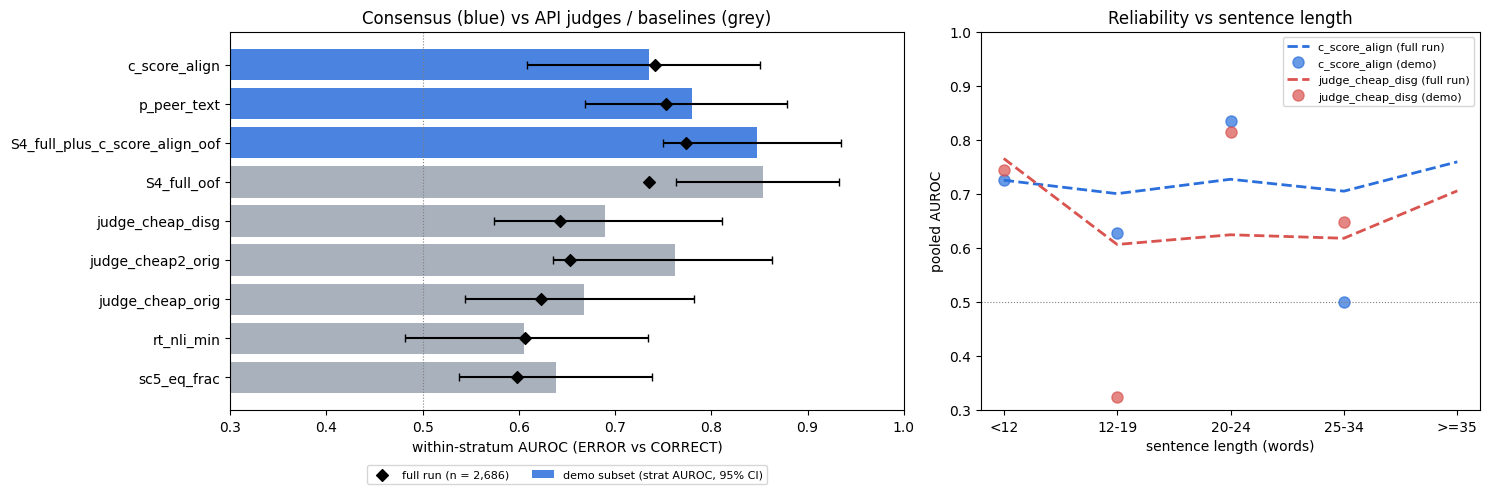

Full-run pre-registered verdict: {'a': 'CONFIRMED', 'b': 'CONFIRMED', 'd': 'CONFIRMED', 'VEX': 'CONFIRMED', 'M3': 'DISCONFIRMED', 'c': 'OTHER ARTIFACT (R_COMP-SIG)', 'e': 'OTHER ARTIFACT', 'overall': 'CONFIRMED'}
Full-run API spend: $2.395; $/item: consensus 1.2e-04, flash-lite 4.9e-05, nano 2.0e-05, frontier 3.7e-03


,metric,strat AUROC,full-run strat,pooled AUROC,full-run pooled,recall@FA0.10,$/item
0,c_score_align,0.736,0.741,0.714,0.782,0.25,0.000121
1,p_peer_text,0.780,0.753,0.757,0.790,0.50,0.000121
2,S4_full_oof,0.853,0.735,0.822,0.777,0.59,NaN
3,S4_full_plus_c_score_align_oof,0.847,0.774,0.801,0.807,0.68,NaN
4,judge_cheap_disg,0.689,0.642,0.671,0.696,0.07,0.000049
5,judge_cheap_orig,0.667,0.623,0.647,0.635,0.39,0.000049
6,judge_cheap2_disg,0.735,0.644,0.728,0.681,0.48,0.000020
7,judge_cheap2_orig,0.762,0.653,0.705,0.700,0.34,0.000020
8,rt_nli_min,0.605,0.606,0.606,0.639,0.30,0.000027
9,sc5_eq_frac,0.638,0.598,0.631,0.656,0.07,0.000029


In [20]:
order = ["c_score_align", "p_peer_text", "S4_full_plus_c_score_align_oof", "S4_full_oof", "judge_cheap_disg",
         "judge_cheap2_orig", "judge_cheap_orig", "rt_nli_min", "sc5_eq_frac"]
order = [m for m in order if m in D and not D[m].get("untestable")]
demo = [D[m]["strat"]["auroc"] for m in order]
lo = [D[m]["strat"]["auroc"] - D[m]["strat"]["ci"][0] for m in order]
hi = [D[m]["strat"]["ci"][1] - D[m]["strat"]["auroc"] for m in order]
full = [REF["metrics_R_AB"].get(m, {}).get("strat_auroc", np.nan) for m in order]
colors = ["#2a6fdb" if m in ("c_score_align", "p_peer_text", "S4_full_plus_c_score_align_oof") else "#9aa4b2" for m in order]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.35, 1]})
yy = np.arange(len(order))[::-1]
ax[0].barh(yy, demo, xerr=[lo, hi], color=colors, alpha=.85, capsize=3, label="demo subset (strat AUROC, 95% CI)")
ax[0].scatter(full, yy, marker="D", color="black", zorder=5, label="full run (n = 2,686)")
ax[0].axvline(.5, color="grey", lw=.8, ls=":")
ax[0].set_yticks(yy, order); ax[0].set_xlim(.3, 1.0); ax[0].set_xlabel("within-stratum AUROC (ERROR vs CORRECT)")
ax[0].set_title("Consensus (blue) vs API judges / baselines (grey)"); ax[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, fontsize=8)

bins = [b for _, _, b in BINS["words"]]
for m, c in (("c_score_align", "#2a6fdb"), ("judge_cheap_disg", "#d9534f")):
    fr = [REF["complexity_words"].get(b, {}).get(m, np.nan) for b in bins]
    dm = [CX["words"].get(b, {}).get("metrics", {}).get(m, {}).get("auroc", np.nan) for b in bins]
    ax[1].plot(bins, fr, ls="--", color=c, lw=2, label=f"{m} (full run)")
    ax[1].plot(bins, dm, ls="", marker="o", color=c, ms=8, alpha=.7, label=f"{m} (demo)")
ax[1].axhline(.5, color="grey", lw=.8, ls=":")
ax[1].set_xlabel("sentence length (words)"); ax[1].set_ylabel("pooled AUROC"); ax[1].set_ylim(.3, 1.0)
ax[1].set_title("Reliability vs sentence length"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.subplots_adjust(bottom=0.2); plt.show()

print("Full-run pre-registered verdict:", REF["verdict"])
print(f"Full-run API spend: ${REF['api_spend_total_usd']:.3f}; $/item: consensus {REF['usd_per_item']['c_score_align']:.1e}, "
      f"flash-lite {REF['usd_per_item']['judge_cheap_disg']:.1e}, nano {REF['usd_per_item']['judge_cheap2_orig']:.1e}, "
      f"frontier {REF['usd_per_item']['judge_strong_orig']:.1e}")
desc_df[["metric", "strat AUROC", "full-run strat", "pooled AUROC", "full-run pooled", "recall@FA0.10", "$/item"]]

## Takeaways

- **Full run.** Peer-agreement consensus (`c_score_align`) beats every paid cheap API judge on held-out NL→FOL
  faithfulness. The margin is stratified ΔAUROC +0.099 over flash-lite disguised and +0.089 over the best cheap judge.
  Consensus also adds signal on top of a stack of all 28 baselines (+0.039). It reaches about 96% of a frontier judge's
  AUROC at about 3% of the cost per item.
- **Where it helps.** The advantage is concentrated in long, heavily conditioned sentences and sentences with
  exceptions: EXC +0.197; 4+ conditions +0.095. On short FOLIO sentences (CTRL, under 12 words) the cheap judge is as
  good or better.
- **Blind spots.** Consensus cannot see errors that the peer pool shares (PEER_ENDORSED, recall 0.00). It also misses
  aligner-masked MEANING_RENAME errors (recall 0.07 vs 0.13–0.20 for the judges).
- **Demo subset.** The notebook re-runs the original parse gate and T1 statistics code on 88 labelled rows, so its CIs
  are wide and small bins are untestable. Set `MAX_ROWS` and `BOOT_B` to the original values and supply the full
  per-item table to reproduce the full-run numbers.